# ENGR 1330 – Computational Thinking and Data Science


## _Power Output Estimator_ Final Project - Background

A combined-cycle power plant uses both a gas and a steam turbine together to produce up to 50% more electricity from the same fuel than a traditional simple-cycle plant. The waste heat from the gas turbine is routed to the nearby steam turbine, which generates extra power. (https://www.gevernova.com/gas-power/resources/education/combined-cycle-power-plants)

Before you begin, read the description of the dataset here: https://archive.ics.uci.edu/dataset/294/combined+cycle+power+plant


## Objective(s):
- Literature study on combined cycle power plant operating principle and how the ambience parameters influence the generated power
- Analyse an existing power generation database and build a data model to predict the power generation output 
- Build an interface to allow users to enter ambience parameters and return an estimated power output with an assessment of the uncertainty in the estimate (by defining a function that takes input parameters and plugs them in into the model that you have found and returns the output)


## Tasks: 

**Literature Research:**
- Briefly describe how the combined cycle power plant generates electricity and explain why a combined cycle plant is preferred over single cycle. 

Some places to start are:

https://en.wikipedia.org/wiki/Combined_cycle_power_plant
    
https://www.sciencedirect.com/science/article/pii/S2214157X2100856X

https://www.hindawi.com/journals/wcmc/2021/9966395/

https://medium.com/analytics-vidhya/prediction-of-the-output-power-of-a-combined-cycle-power-plant-using-machine-learning-a2ca01848eea



**Exploratory Data Analysis**
- Describe (in words) the database.
- Reformat as needed (column headings perhaps) the database for subsequent analysis.

**Model Building**
- Build a regression model to estimate power output (PE)using the 4 inputs.
- Assess the model quality
- Build the input data interface for using the model (by defining a function that takes input parameters and plugs them in into the model that you have found and returns the output)
- Using your model determine projected total power output for 5 possible ambience parameters given in the table below:

Table of 5 ambience scenarios is provided in the course handout/Canvas.\n


                
       
**Documentation**
- Training video on how to use your tool, and demonstrate the tool(s) as they are run
- Interim report (see deliverables below); this document must be rendered as a .pdf.
- Final ipynb file (see deliverables below)

## Deliverables:

#### Part 1: Interim report
A report that briefly describes the project. Use the Interim Report Template in Raider Canvas.  
- Break down each task into manageable subtasks and describe how you intend to solve the subtasks and how you will test each task. (Perhaps make a simple Gantt Chart) or list of meeting times. 
- Address the responsibilities of each team member for tasks completed and tasks to be completed until the end of the semester. (Perhaps make explicit subtask assignments)  

#### Part 2: Final report
- A well-documented JupyterLab (using a python kernel), use markdown cells and commenting for explanations and text. 
- A how-to video demonstrating performance and description of problems that you were not able to solve and also talk about project management such as who did what. Active participation of every single group member is mandatory in the presentation. 
- A final peer evaluation report, where each group member should rate the participation and contribution of the other members.

**Above items can reside in a single video; but structure the video into the two parts; use an obvious transition when moving from "how to ..." into the project management portion.**  Keep the total video length to less than 10 minutes; submit as an *unlisted* YouTube video, and just supply the link (someone on each team is likely to have a YouTube account).  Keep in mind a 10 minute video can approach 100MB file size before compression, so it won't upload to Raider Canvas and cannot be emailed.

## Authors and background

**Group:** Sander Garita (R11975813), Alexandra Schäffer (R12014866), Diana Rodriguez (R12062080)

A combined cycle plant uses a gas turbine and a steam section linked by a heat recovery system, so more of the fuel’s energy becomes electricity than in a simple open-cycle gas plant. The CSV we analyze lists hourly full-load operation with ambient conditions and the corresponding electrical output, which we model below.


## Literature Research

### Combined-Cycle vs. Simple-Cycle Power Plants

A combined-cycle power plant uses both a gas turbine and a steam turbine in series. The gas turbine (Brayton cycle) burns fuel and produces hot exhaust. Instead of dumping this waste heat, a heat-recovery steam generator (HRSG) uses it to drive a steam turbine (Rankine cycle). In contrast, a simple-cycle gas turbine discards its exhaust heat to the atmosphere.

By extracting useful work from the exhaust, a combined-cycle plant greatly boosts efficiency. Modern combined-cycle plants often exceed 55–60% efficiency, whereas simple-cycle gas turbines are typically under 40%. The EIA reports a typical combined-cycle heat rate of ~7,146 Btu/kWh vs ~10,000 Btu/kWh for simple-cycle units. This makes combined-cycle plants more economical for base/intermediate grid demand, while simple-cycle units are better suited for peak loads where fast ramp-up matters more than efficiency.

### How Ambient Conditions Affect Output

The four input variables in this dataset map directly to physical mechanisms:

- **AT (Ambient Temperature):** Higher temperature means less dense intake air, reducing mass flow through the compressor and lowering gas-turbine output. Roughly every 10°C rise above standard conditions cuts output by 5–10%.
- **AP (Ambient Pressure):** Lower ambient pressure (e.g. high altitude or low barometer) reduces the oxygen mass per unit volume, decreasing gas-turbine output. Higher pressure boosts it.
- **RH (Relative Humidity):** Water vapor is lighter than dry air, so hot and humid conditions reduce air density and gas-turbine output further.
- **V (Exhaust Vacuum):** This reflects the steam-cycle back-pressure. A stronger vacuum (lower condenser pressure) allows steam to expand more, extracting more work and raising output.

These relationships predict the correlations we observe in the data: PE decreases with higher AT and RH, and increases with higher AP and stronger vacuum (V).

### Prior Work

Tüfekci & Kaya (2014) compared several regression methods on this dataset and found ensemble methods (bagging with REPTree) performed best, achieving MAE ≈ 2.82 MW and RMSE ≈ 3.79 MW. Subsequent studies using neural networks reported R² ≈ 0.93–0.97 for stronger nonlinear learners. Our multilinear OLS model still achieves a high test-set R² with the four ambient inputs alone (see metrics below), which matches the strong linear structure visible in the data even though more flexible models can reduce error further.




In [8]:
# =============================================================================
# ENGR 1330 — Combined Cycle Power Plant (CCPP) notebook: imports & data path
# =============================================================================
# This cell loads third-party libraries and resolves the location of `ccpp.csv`.
# The UCI CCPP dataset has four ambient/operating inputs (AT, V, AP, RH) and
# one target: PE (net hourly electrical energy output, MW). We use scikit-learn
# for OLS linear regression and standard regression metrics.
# =============================================================================

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

# Fixed seed so train/test split and any random sampling (e.g. pairplot) are
# reproducible across runs and match the write-up.
RANDOM_STATE = 42


def _find_data_file() -> Path:
    """Locate `ccpp.csv` on disk regardless of the notebook's working directory.

    Jupyter kernels often start in the notebook folder, but opening the repo
    from another cwd (e.g. repo root) is common. We try a small ordered list of
    relative paths and return the first file that exists.

    Returns
    -------
    pathlib.Path
        Absolute path to the resolved CSV file.

    Raises
    ------
    FileNotFoundError
        If none of the candidate paths exist.
    """
    for candidate in (
        Path("ccpp.csv"),
        Path("5power") / "ccpp.csv",
        Path("final proj") / "5power" / "ccpp.csv",
    ):
        if candidate.is_file():
            return candidate.resolve()
    raise FileNotFoundError(
        "Could not find ccpp.csv next to the notebook or under final proj/5power/."
    )


# Resolved once per kernel session; used by the next cell for `pd.read_csv`.
DATA_PATH = _find_data_file()
print(DATA_PATH)



/Users/dianarodriguez/Desktop/computational thinking theory/Project/ccpp.csv


## Code organization

Run **Kernel → Restart & Run All** so names (`df`, `model`, `TEST_RMSE`, …) exist in order. The pipeline is:

- **Imports & data path** — Third-party libraries, `RANDOM_STATE`, and `_find_data_file()` so `ccpp.csv` resolves whether the kernel cwd is the notebook folder, `5power/`, or repo root under `final proj/5power/`.
- **Load** — `pd.read_csv(DATA_PATH)` into `df`; trailing `head()` for preview output.
- **EDA** — Table summaries (`info`, `describe`, missing counts) then a correlation heatmap and a subsampled `pairplot` for multivariate shape.
- **Model** — 80/20 `train_test_split`, `LinearRegression` fit on `feature_cols`, test-set RMSE/MAE/R² stored in `TEST_RMSE`, `TEST_MAE`, `TEST_R2` for reuse.
- **Diagnostics** — Residuals vs fitted on the held-out test set.
- **`predict_power`** — Docstring API: point PE from `(AT, V, AP, RH)` plus an approximate ±`1.96 × TEST_RMSE` band documented in the function.
- **Scenarios** — Five rows iterated through `predict_power` into a results `DataFrame`.

Each code cell uses block comments at the top of major steps; functions use docstrings (Google/NumPy style where helpful).


## Data

The file is the *Combined Cycle Power Plant* data from the [UCI repository](https://archive.ics.uci.edu/dataset/294/combined+cycle+power+plant) (full load, 2006–2011). Each row is an hourly average. Inputs are ambient temperature `AT` (°C), exhaust vacuum `V` (cm Hg), ambient pressure `AP` (mbar), and relative humidity `RH` (%). The target is net hourly output `PE` (MW). We use the copy shipped with this project as `ccpp.csv`.


In [9]:
# Load the full dataset into memory as a pandas DataFrame.
# Column names follow the UCI naming convention: AT, V, AP, RH, PE.
# `df.head()` displays the first five rows as a quick sanity check on dtypes
# and value ranges (the trailing expression is the cell's rich output).
df = pd.read_csv(DATA_PATH)
df.head()



,AT,V,AP,RH,PE
0,14.96,41.76,1024.07,73.17,463.26
1,25.18,62.96,1020.04,59.08,444.37
2,5.11,39.40,1012.16,92.14,488.56
3,20.86,57.32,1010.24,76.64,446.48
4,10.82,37.50,1009.23,96.62,473.90


## Exploratory analysis

The table has four numeric predictors and one response. The summary and correlation plot below show how the variables line up; there are no missing entries in this file.


In [10]:
# Exploratory summaries:
# - Row count: confirm we match the published ~9.5k hourly records.
# - `info()`: dtypes and non-null counts (should be all numeric, no gaps).
# - `describe()`: five-number style stats + mean/std for each column.
# - `isna().sum()`: per-column missing counts (UCI version is typically clean).
print(len(df), "rows")
df.info()
df.describe()
print(df.isna().sum())



9568 rows
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9568 entries, 0 to 9567
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   AT      9568 non-null   float64
 1   V       9568 non-null   float64
 2   AP      9568 non-null   float64
 3   RH      9568 non-null   float64
 4   PE      9568 non-null   float64
dtypes: float64(5)
memory usage: 373.9 KB
AT    0
V     0
AP    0
RH    0
PE    0
dtype: int64


**Figure 1.** Correlation matrix of all variables. Strong negative correlation between `PE` and both `AT` and `V` is visible; `AP` and `RH` are also associated with `PE` but more weakly.


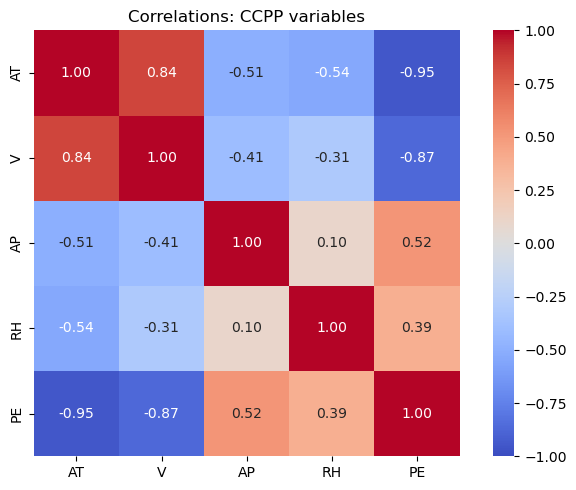

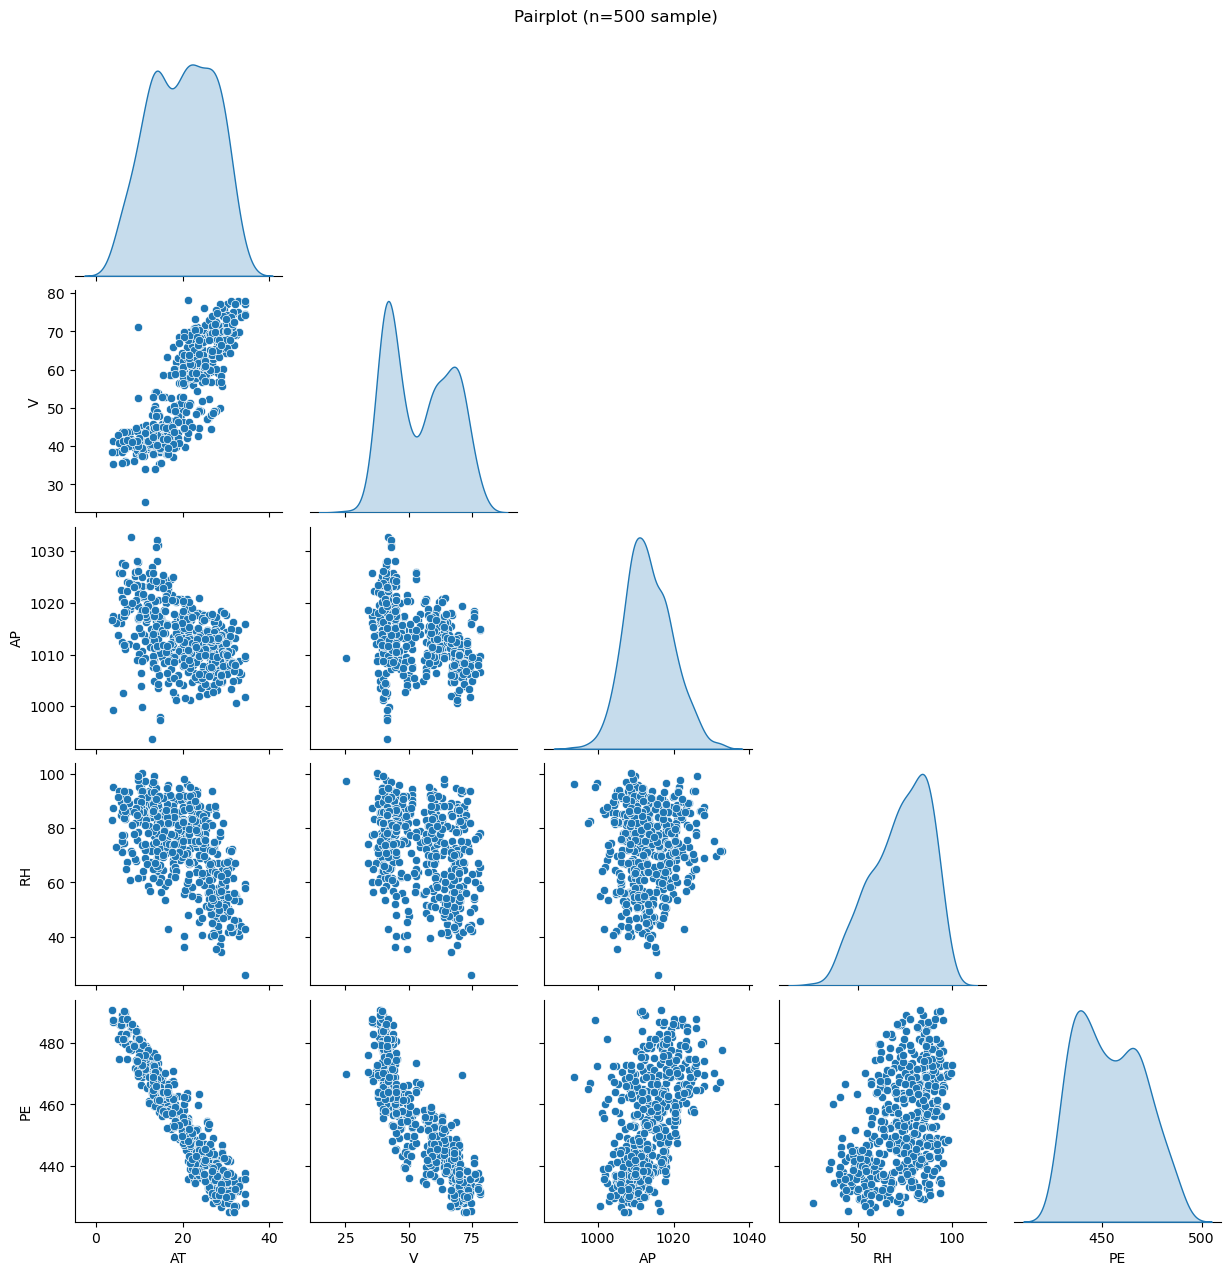

In [11]:
# Figure 1 — Correlation heatmap of all variables (predictors + PE).
# Pearson correlation measures *linear* association; strong |r| near PE guides
# expectations for multilinear regression. Coolwarm diverging map centers at 0.
plt.figure(figsize=(7, 5))
sns.heatmap(df.corr(), annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1, square=True)
plt.title("Correlations: CCPP variables")
plt.tight_layout()
plt.show()

# Pairplot on a random subsample: full n≈9500 makes the scatter matrix slow and
# visually dense. `corner=True` shows only the lower triangle; `diag_kind="kde"`
# smooths 1D marginal distributions on the diagonal.
sample = df.sample(n=min(500, len(df)), random_state=RANDOM_STATE)
sns.pairplot(sample, corner=True, diag_kind="kde")
plt.suptitle("Pairplot (n=500 sample)", y=1.02)
plt.show()



## Models and test-set error

We hold out 20% of the rows for testing (`random_state=42`) and use the remaining 80% for training.

We fit **ordinary least squares (OLS) linear regression** on the four ambient inputs (AT, V, AP, RH), consistent with the multivariate (multilinear) regression framework from Lecture 23. We report RMSE, MAE, and R² on the held-out test set.



In [13]:
# ---------------------------------------------------------------------------
# Multilinear OLS regression (Lecture 23): predict PE from four features.
# ---------------------------------------------------------------------------
# Design matrix X: each row is one hour; columns are AT, V, AP, RH.
# Response y: PE (MW). sklearn.LinearRegression fits coefficients β that
# minimize sum squared residuals ||y - Xβ||² (ordinary least squares).
# ---------------------------------------------------------------------------

feature_cols = ["AT", "V", "AP", "RH"]
X = df[feature_cols]
y = df["PE"]

# Hold out 20% for *honest* out-of-sample metrics. The model never sees y_test
# during `.fit()`, so RMSE/MAE/R² on the test set reflect generalization better
# than training-set scores. `shuffle=True` is default; stratify is N/A for regression.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

# `fit_intercept=True` (default): adds constant term so PE need not be zero when
# all inputs are zero (physically meaningless but statistically standard).
model = LinearRegression()
model.fit(X_train, y_train)
y_hat_test = model.predict(X_test)

# --- Test-set metrics (all in MW except R², which is unitless in [−∞, 1]) ---
# RMSE: sqrt(mean squared error); penalizes large errors more than MAE.
# MAE: mean absolute error; robust, same units as PE.
# R²: fraction of variance in y_test explained by linear predictions (1 = perfect).
mse = mean_squared_error(y_test, y_hat_test)
TEST_RMSE = float(np.sqrt(mse))
TEST_MAE = float(mean_absolute_error(y_test, y_hat_test))
TEST_R2 = float(r2_score(y_test, y_hat_test))

print("Linear (OLS) on test set")
print(f"  RMSE={TEST_RMSE:.4f}  MAE={TEST_MAE:.4f}  R2={TEST_R2:.4f}")
print("Test RMSE (MW):", TEST_RMSE)
print("Test MAE (MW):", TEST_MAE)




Linear (OLS) on test set
  RMSE=4.5026  MAE=3.5959  R2=0.9301
Test RMSE (MW): 4.5026332295321865
Test MAE (MW): 3.5959131782734066


**Figure 2.** Residuals (actual minus predicted) versus predicted `PE` on the test set for the model above. The cloud should be centered near zero; a few large residuals are expected on real plant data.


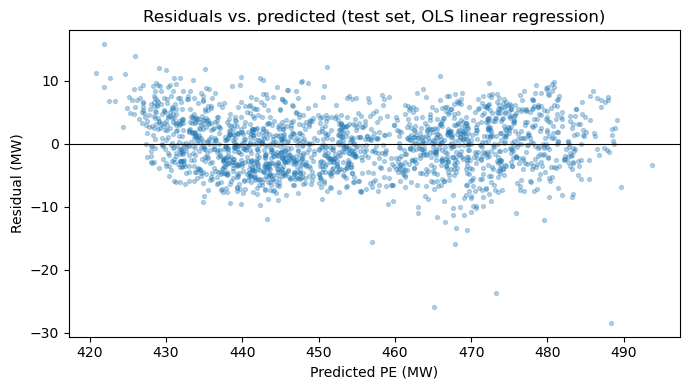

In [14]:
# Residual plot: e = y - ŷ vs ŷ on the test set.
# For a well-behaved linear model we hope for a *horizontal* cloud around 0 with
# no strong funnel (heteroscedasticity) or curvature (nonlinearity). Systematic
# patterns may suggest missing terms or outliers worth investigating.
residuals = y_test - y_hat_test
plt.figure(figsize=(7, 4))
plt.scatter(y_hat_test, residuals, alpha=0.3, s=8)
plt.axhline(0, color="k", lw=0.8)
plt.xlabel("Predicted PE (MW)")
plt.ylabel("Residual (MW)")
plt.title("Residuals vs. predicted (test set, OLS linear regression)")
plt.tight_layout()
plt.show()



## Prediction function

The prediction function uses the multilinear regression model. The uncertainty band is ±1.96 × test RMSE, a practical approximation assuming approximately normal residuals.

`predict_power` returns a point estimate in MW. The half-width of the range uses 1.96 times the test RMSE, as a rough 95%-style band if the errors were close to normal (common in class projects; it is an approximation, not a formal guarantee).


In [15]:
def predict_power(AT, V, AP, RH, return_interval=True):
    """Predict net power output (PE) from ambient inputs using the fitted OLS model.

    The global `model` is trained in an earlier cell on `feature_cols`. Inputs must
    be in the same units as the CSV (see UCI dataset description). The optional
    uncertainty band reuses **TEST_RMSE** from the held-out test set: half-width
    ``z * TEST_RMSE`` with ``z = 1.96`` approximates a 95% interval *if* residuals
    were i.i.d. Normal with constant variance — a classroom simplification, not a
    formal prediction interval (which would account for estimation error in β).

    Parameters
    ----------
    AT : float
        Ambient temperature (°C).
    V : float
        Exhaust vacuum / steam turbine vacuum gauge (cm Hg).
    AP : float
        Ambient pressure (millibar).
    RH : float
        Relative humidity (%).
    return_interval : bool, default True
        If False, return only the scalar point prediction (MW).

    Returns
    -------
    float or dict
        If ``return_interval`` is False: predicted PE in MW.
        Otherwise a dict with keys:
        - ``PE_hat_MW``: point prediction.
        - ``test_RMSE_MW``: RMSE used to build the band (for transparency).
        - ``approx_range_MW``: ``(low, high)`` symmetric interval around the point.
    """
    # sklearn expects a 2D array-like with column names matching training data.
    row = pd.DataFrame([[AT, V, AP, RH]], columns=feature_cols)
    pe_hat = float(model.predict(row)[0])
    if not return_interval:
        return pe_hat
    z = 1.96  # Standard normal 97.5% quantile; two-sided ~95% if Normal holds.
    lo, hi = pe_hat - z * TEST_RMSE, pe_hat + z * TEST_RMSE
    return {
        "PE_hat_MW": pe_hat,
        "test_RMSE_MW": TEST_RMSE,
        "approx_range_MW": (lo, hi),
    }


# Example call: matches the same feature order as `feature_cols`.
predict_power(25.0, 60.0, 1013.0, 70.0)



{'PE_hat_MW': 442.9362706192272,
 'test_RMSE_MW': 4.5026332295321865,
 'approx_range_MW': (434.1111094893441, 451.7614317491103)}

## Scenarios

**Table — predicted output for five ambient conditions.**


In [16]:
# Five user-defined ambient scenarios (replace with Canvas table values if required).
# Each row is passed to `predict_power`; results are collected into a summary table
# with point prediction and approximate ±1.96·RMSE bounds (see docstring above).
scenarios = pd.DataFrame(
    {
        "AT": [10.0, 20.0, 15.0, 25.0, 5.0],
        "V": [40.0, 55.0, 50.0, 60.0, 45.0],
        "AP": [1013.0, 1010.0, 1015.0, 1008.0, 1020.0],
        "RH": [70.0, 65.0, 80.0, 55.0, 90.0],
    }
)

out = []
for _, r in scenarios.iterrows():
    p = predict_power(r["AT"], r["V"], r["AP"], r["RH"])
    out.append(
        {
            "AT": r["AT"],
            "V": r["V"],
            "AP": r["AP"],
            "RH": r["RH"],
            "PE_pred_MW": p["PE_hat_MW"],
            "range_low_MW": p["approx_range_MW"][0],
            "range_high_MW": p["approx_range_MW"][1],
        }
    )
pd.DataFrame(out)



,AT,V,AP,RH,PE_pred_MW,range_low_MW,range_high_MW
0,10.0,40.0,1013.0,70.0,477.366638,468.541476,486.191799
1,20.0,55.0,1010.0,65.0,454.630226,445.805065,463.455387
2,15.0,50.0,1015.0,80.0,463.659425,454.834264,472.484586
3,25.0,60.0,1008.0,55.0,444.997038,436.171877,453.822199
4,5.0,45.0,1020.0,90.0,483.408712,474.583551,492.233873


In [21]:
#model.coef_ contains the coefficients (slopes) for each input feature.
print(model.coef_)
# model.intercept_ is the baseline value of PE when all inputs are zero.
# This is the "starting point" of the regression equation.
print(model.intercept_)

[-1.98589969 -0.23209358  0.06219991 -0.15811779]
454.56911458941414


In [24]:
def foo(x1, x2, x3, x4):
    pred = 454.56911458941414 + -1.98589969  * x1 + -0.23209358 * x2 + 0.06219991 * x3 + -0.15811779 * x4
    return pred

x_at = float(input('Enter Ambiente Temperature (AT)'))
x_v = float(input('Enter Exhaust Vacuum (V)'))
x_ap = float(input('Enter Ambient Pressure (AP) '))
x_rh = float(input('Enter Relative Humidity (RH)'))
y_pe = foo(x_at, x_v, x_ap, x_rh)
print(f'The estimated pe is {y_pe} ')

Enter Ambiente Temperature (AT) 5.11
Enter Exhaust Vacuum (V) 39.40
Enter Ambient Pressure (AP)  1012.16
Enter Relative Humidity (RH) 92.14


The estimated pe is 483.6639678565142 
